# Comprehensive Analysis of Pickle Dataset

This notebook provides a detailed analysis of the serialized skeleton dataset (Pickle format). It covers:

- **Data Structure**: Root object type and sample fields.
- **Global Statistics**: Distribution of sequence lengths and coordinate ranges.
- **Data Integrity**: Assessment of missing landmarks (zero-value coordinates).
- **Spatial Segmentation**: Breakdown of the 86 keypoints into specific body regions (Hands, Mouth, Pose).
- **Visualization**: Graphical representation of the skeleton keypoints.
- **Signer Analysis**: Distribution of sequence lengths across different signers (penutur).

## 1. Setup and Data Loading

Initialize libraries and load the dataset from the specified path.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configuration
PICKLE_FILE_PATH = Path("../data/pickle/pose_bisindo.pkl")

print(f"Loading dataset from: {PICKLE_FILE_PATH}")
with open(PICKLE_FILE_PATH, "rb") as f:
    dataset = pickle.load(f)
print(f"Dataset Loaded.")

Loading dataset from: ..\data\pickle\pose_bisindo.pkl
Dataset Loaded.


## 2. Basic Structure Exploration

Inspecting the internal structure of the samples and the format of the keypoint arrays.

In [2]:
from pprint import pprint
import numpy as np

print("=" * 60)
print("HASIL INSPEKSI STRUKTUR DATASET SKELETON")
print("=" * 60)

print(f"Path File Dataset         : {PICKLE_FILE_PATH}")
print(f"Tipe Objek Utama          : {type(dataset).__name__}")
print(f"Jumlah Sampel Video       : {len(dataset)}")

# Contoh key
sample_key = next(iter(dataset.keys()))
sample_value = dataset[sample_key]
keypoints = sample_value["keypoints"]

print(f"Contoh Key (ID Video)     : {sample_key}")
print(f"Tipe Data Key             : {type(sample_key).__name__}")

# Informasi value
print(f"Tipe Data Value           : {type(sample_value).__name__}")
print(f"Field pada Value          : {list(sample_value.keys())}")
print(f"Tipe Data Keypoints       : {type(keypoints).__name__}")
print(f"Dimensi Data              : {keypoints.shape}")
print(f"Tipe Nilai Data           : {keypoints.dtype}")
print(f"Rentang Koordinat         : {keypoints.min():.4f} s.d. {keypoints.max():.4f}")


if not isinstance(dataset, dict):
    raise TypeError(
        f"Dataset harus berupa dictionary, tetapi ditemukan {type(dataset)}"
    )

video_ids = list(dataset.keys())

print(f"Value dari dictionary: {list(dataset.values())[:1]} ...")

# ------------------------------------------------------------------

sample_id = video_ids[0]
sample_data = dataset[sample_id]

print("\n" + "-" * 60)
print(f"INSPEKSI CONTOH DATA ({sample_id})")
print("-" * 60)

print(f"Tipe Data Sampel          : {type(sample_data).__name__}")

if isinstance(sample_data, dict):
    print(f"Field yang Tersedia       : {', '.join(sample_data.keys())}")

keypoints = sample_data.get("keypoints") if isinstance(sample_data, dict) else None

if isinstance(keypoints, np.ndarray):
    print(f"Tipe Data Keypoint        : {type(keypoints).__name__}")
    print(f"Dimensi Data             : {keypoints.shape}")
    print(f"Tipe Nilai Data          : {keypoints.dtype}")
    print(f"Rentang Koordinat        : {keypoints.min():.4f} s.d. {keypoints.max():.4f}")
else:
    print("Field 'keypoints' tidak ditemukan atau bukan NumPy Array.")

# ------------------------------------------------------------------
# Visualisasi struktur file .pkl
# ------------------------------------------------------------------

print("\n" + "=" * 60)
print("VISUALISASI STRUKTUR FILE .PKL")
print("=" * 60)

print("{")
print(f'    "{sample_id}": {{')
print('        "keypoints": ndarray')
print(f"            Shape  : {keypoints.shape}")
print(f"            DType  : {keypoints.dtype}")
print("    },")
print('    "...": { ... }')
print("}")

# ------------------------------------------------------------------
# Contoh isi array
# ------------------------------------------------------------------

print("\n" + "=" * 60)
print("CONTOH STRUKTUR ARRAY KEYPOINTS")
print("=" * 60)

print(f"""
keypoints
└── ndarray {keypoints.shape}
    ├── Frame 1
    │   ├── Keypoint 1   : {keypoints[0,0]}
    │   ├── Keypoint 2   : {keypoints[0,1]}
    │   ├── ...
    │   └── Keypoint 86  : {keypoints[0,-1]}
    ├── Frame 2
    │   └── ...
    └── Frame {keypoints.shape[0]}
""")

print("=" * 60)

HASIL INSPEKSI STRUKTUR DATASET SKELETON
Path File Dataset         : ..\data\pickle\pose_bisindo.pkl
Tipe Objek Utama          : dict
Jumlah Sampel Video       : 807
Contoh Key (ID Video)     : P1_S01_R1
Tipe Data Key             : str
Tipe Data Value           : dict
Field pada Value          : ['keypoints']
Tipe Data Keypoints       : ndarray
Dimensi Data              : (115, 86, 2)
Tipe Nilai Data           : float64
Rentang Koordinat         : 0.0000 s.d. 1.3729
Value dari dictionary: [{'keypoints': array([[[0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        ...,
        [0.42639479, 0.74767935],
        [0.56873304, 1.14533222],
        [0.43926615, 1.13983214]],

       [[0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        ...,
        [0.43487805, 0.7261771 ],
        [0.56905633, 1.15868151],
        [0.43060637, 1.14595592]],

       [[0.        , 0.        ],
        [0.        

## 3. Global Statistical Analysis

Analyzing distribution of sequence lengths and ensuring consistency across the entire dataset.

In [3]:
sequence_lengths = []
shape_registry = {}
dtype_registry = {}
invalid_samples = []

global_min = np.inf
global_max = -np.inf

for vid, data in dataset.items():
    keypoints = data.get("keypoints") if isinstance(data, dict) else None

    if not isinstance(keypoints, np.ndarray):
        invalid_samples.append((vid, type(keypoints)))
        continue

    sequence_lengths.append(keypoints.shape[0])

    # Register spatial dimensions (86, 2)
    spatial_shape = tuple(keypoints.shape[1:])
    shape_registry[spatial_shape] = shape_registry.get(spatial_shape, 0) + 1

    # Register data type
    dtype_str = str(keypoints.dtype)
    dtype_registry[dtype_str] = dtype_registry.get(dtype_str, 0) + 1

    # Track global coordinate range
    curr_min = np.min(keypoints)
    curr_max = np.max(keypoints)
    if curr_min < global_min: global_min = curr_min
    if curr_max > global_max: global_max = curr_max

sequence_lengths = np.array(sequence_lengths)

print(f"Total Samples Analyzed: {len(dataset)}")
print(f"Valid NumPy Samples: {len(sequence_lengths)}")
print(f"Invalid Samples Found: {len(invalid_samples)}")

print("\n--- Spatial Shape Distribution ---")
for shape, count in sorted(shape_registry.items(), key=lambda x: x[1], reverse=True):
    print(f"  {shape}: {count} samples")

print("\n--- Sequence Length Statistics (Frames) ---")
print(f"  Min Length    : {int(sequence_lengths.min())}")
print(f"  25th Percentile: {np.percentile(sequence_lengths, 25):.2f}")
print(f"  Median Length : {np.median(sequence_lengths):.2f}")
print(f"  Mean Length   : {sequence_lengths.mean():.2f}")
print(f"  75th Percentile: {np.percentile(sequence_lengths, 75):.2f}")
print(f"  Max Length    : {int(sequence_lengths.max())}")

print("\n--- Global Coordinate Range ---")
print(f"  Min Value: {global_min:.6f}")
print(f"  Max Value: {global_max:.6f}")

Total Samples Analyzed: 807
Valid NumPy Samples: 807
Invalid Samples Found: 0

--- Spatial Shape Distribution ---
  (86, 2): 807 samples

--- Sequence Length Statistics (Frames) ---
  Min Length    : 81
  25th Percentile: 150.00
  Median Length : 195.00
  Mean Length   : 202.00
  75th Percentile: 240.00
  Max Length    : 517

--- Global Coordinate Range ---
  Min Value: -0.090984
  Max Value: 1.788204


## 4. Data Integrity: Missing Landmarks

Coordinates at `[0.0, 0.0]` usually indicate that MediaPipe failed to detect those landmarks in a frame.

In [29]:
total_frames_count = 0
total_landmarks_count = 0
missing_landmarks_count = 0
frames_with_missing_data = 0

for data in dataset.values():
    keypoints = data.get("keypoints") if isinstance(data, dict) else None
    if not isinstance(keypoints, np.ndarray) or keypoints.ndim != 3:
        continue

    # Identify landmarks where both X and Y are zero
    # Shape: (Frames, 86, 2) -> missing_mask: (Frames, 86)
    missing_mask = np.all(keypoints == 0, axis=2)

    num_frames = keypoints.shape[0]
    num_landmarks = keypoints.shape[1]

    total_frames_count += num_frames
    total_landmarks_count += num_frames * num_landmarks
    
    missing_landmarks_count += int(missing_mask.sum())
    frames_with_missing_data += int(np.any(missing_mask, axis=1).sum())

print("--- Data Integrity Summary ---")
print(f"Total Frames in Dataset       : {total_frames_count}")
print(f"Frames with Missing Landmarks : {frames_with_missing_data}")
print(f"Percentage of Affected Frames : {(frames_with_missing_data / total_frames_count * 100):.2f}%")

print(f"\nTotal Keypoint Values Checked : {total_landmarks_count}")
print(f"Total Missing [0,0] Keypoints : {missing_landmarks_count}")
print(f"Overall Missing Data Rate    : {(missing_landmarks_count / total_landmarks_count * 100):.2f}%")

--- Data Integrity Summary ---
Total Frames in Dataset       : 121054
Frames with Missing Landmarks : 68677
Percentage of Affected Frames : 56.73%

Total Keypoint Values Checked : 10410644
Total Missing [0,0] Keypoints : 1785425
Overall Missing Data Rate    : 17.15%


## 5. Body Region Segmentation

Breaking down the 86 keypoints into their semantic regions based on the Holistic extractor layout.

In [29]:
# Select a sample for inspection
target_id = video_ids[2] if len(video_ids) > 2 else video_ids[0]
kp_array = dataset[target_id]["keypoints"]

print(f"Analyzing Segmentation for: {target_id}")
print(f"Array Shape: {kp_array.shape}")

# Slicing based on the 86-point layout:
# 0-20: Left Hand | 21-41: Right Hand | 42-60: Mouth | 61-85: Pose
left_hand  = kp_array[:, 0:21, :]
right_hand = kp_array[:, 21:42, :]
mouth      = kp_array[:, 42:61, :]
pose       = kp_array[:, 61:86, :]

print("\n--- Regional Shapes ---")
print(f"  Left Hand  : {left_hand.shape}")
print(f"  Right Hand : {right_hand.shape}")
print(f"  Mouth      : {mouth.shape}")
print(f"  Pose       : {pose.shape}")

print("\nFirst 5 points of Left Hand in Frame 0:")
np.set_printoptions(precision=4, suppress=True)
print(left_hand[0, :5, :])

Analyzing Segmentation for: 00_0003
Array Shape: (98, 86, 2)

--- Regional Shapes ---
  Left Hand  : (98, 21, 2)
  Right Hand : (98, 21, 2)
  Mouth      : (98, 19, 2)
  Pose       : (98, 25, 2)

First 5 points of Left Hand in Frame 0:
[[ 895.3658  892.9287]
 [ 939.2323  874.0457]
 [ 981.9089  872.7719]
 [1019.8629  883.7686]
 [1050.1979  892.8824]]


## 6. Visualization

Visualizing the skeleton for multiple speakers to verify spatial alignment. Note that Y-axis is inverted to match image coordinate systems (origin at top-left).

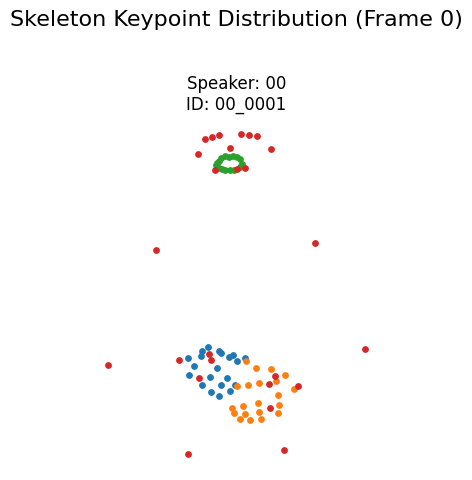

In [32]:
def filter_valid_points(points):
    """Removes [0,0] points from the plotting array."""
    mask = ~(np.logical_and(points[:, 0] == 0, points[:, 1] == 0))
    return points[mask]

# speakers_to_plot = ["P1", "P2", "P3", "P4", "P5", "P6", "00"]
speakers_to_plot = ["00"]
selection = {}

for vid in dataset.keys():
    spk = vid.split('_')[0]
    if spk in speakers_to_plot and spk not in selection:
        selection[spk] = vid
    if len(selection) == len(speakers_to_plot): break

if selection:
    fig, axes = plt.subplots(1, len(selection), figsize=(20, 5))
    if len(selection) == 1: axes = [axes]

    for ax, (spk, vid) in zip(axes, sorted(selection.items())):
        kp = dataset[vid]["keypoints"][0]  # Take first frame
        
        # Region Segmentation for plotting
        pts_lh = filter_valid_points(kp[0:21])
        pts_rh = filter_valid_points(kp[21:42])
        pts_mo = filter_valid_points(kp[42:60])
        pts_po = filter_valid_points(kp[60:86])

        ax.scatter(pts_lh[:, 0], -pts_lh[:, 1], s=15, label="Left Hand")
        ax.scatter(pts_rh[:, 0], -pts_rh[:, 1], s=15, label="Right Hand")
        ax.scatter(pts_mo[:, 0], -pts_mo[:, 1], s=15, label="Mouth")
        ax.scatter(pts_po[:, 0], -pts_po[:, 1], s=15, label="Pose")

        ax.set_title(f"Speaker: {spk}\nID: {vid}")
        ax.set_aspect('equal')
        ax.axis('off')
    
    plt.suptitle("Skeleton Keypoint Distribution (Frame 0)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No samples found for visualization.")

## 7. Signer Analysis (Penutur)

Analyzing the distribution of frame lengths across different signers to ensure data consistency and identify variations in signing speed or recording duration.

--- Signer Frame Length Statistics ---


,Signer,Count,Min,Mean,Median,Max,Std
0,P1,120,95,186.59,190,305,57.00
1,P2,120,125,223.19,215,390,64.20
2,P3,120,81,172.23,168,312,48.79
3,P4,120,96,250.18,232,485,82.74
4,P5,120,95,176.58,179,295,46.48


C:\Users\IKAJTK\AppData\Local\Temp\ipykernel_1248\806087047.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=sorted(signer_frame_lengths.keys()))


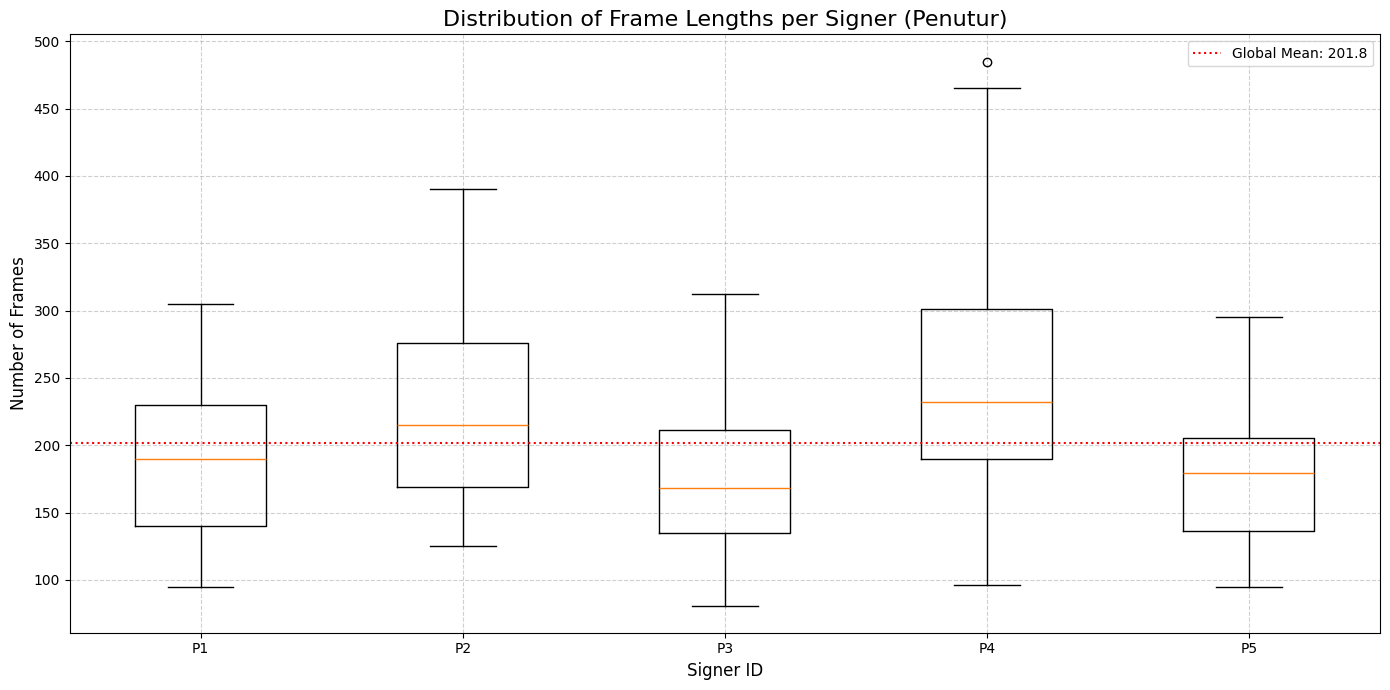

In [32]:
import pandas as pd

# 1. Group frame lengths by Signer ID (Pxx)
signer_frame_lengths = {}
for vid, data in dataset.items():
    signer_id = vid.split('_')[0]
    num_frames = data['keypoints'].shape[0]
    
    if signer_id not in signer_frame_lengths:
        signer_frame_lengths[signer_id] = []
    signer_frame_lengths[signer_id].append(num_frames)

# 2. Calculate summary statistics per signer
signer_stats = []
for signer, lengths in sorted(signer_frame_lengths.items()):
    lengths = np.array(lengths)
    signer_stats.append({
        'Signer': signer,
        'Count': len(lengths),
        'Min': int(lengths.min()),
        'Mean': round(lengths.mean(), 2),
        'Median': int(np.median(lengths)),
        'Max': int(lengths.max()),
        'Std': round(lengths.std(), 2)
    })

df_signer = pd.DataFrame(signer_stats)
print("--- Signer Frame Length Statistics ---")
display(df_signer)

# 3. Visualization: Boxplot of distributions
plt.figure(figsize=(14, 7))
data_to_plot = [lengths for signer, lengths in sorted(signer_frame_lengths.items())]
plt.boxplot(data_to_plot, labels=sorted(signer_frame_lengths.keys()))
plt.title("Distribution of Frame Lengths per Signer (Penutur)", fontsize=16)
plt.xlabel("Signer ID", fontsize=12)
plt.ylabel("Number of Frames", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add average line
plt.axhline(y=np.mean(sequence_lengths), color='r', linestyle=':', label=f"Global Mean: {np.mean(sequence_lengths):.1f}")
plt.legend()
plt.tight_layout()
plt.show()